# **Employee Attendance & Productivity — Data Analysis**

## **Objective**

The objective of this analysis is to understand employee attendance,
productivity, punctuality, work mode, shift, and department-level patterns
for the Bangalore workforce during Q1 2026.

The analysis aims to identify important trends and relationships in the
data and use these findings to support the final interactive dashboard.

## **1. Environment Setup :**

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

## **2. Load the Cleaned Dataset :**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CLEANED_PATH = "/content/drive/MyDrive/employee_attendance_bangalore_q1_2026_cleaned.csv"
df = pd.read_csv(CLEANED_PATH)
df.head()

,employee_id,gender,department,designation,employment_type,office_location,date_of_joining,attendance_date,shift_type,attendance_status,work_mode,login_timestamp,logout_timestamp,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours,leave_type,attendance_month,attendance_weekday,tenure_days,is_late,is_early_exit,productivity_ratio
0,VL1000,Male,Engineering,Software Engineer Intern,Intern,Koramangala HQ,2025-06-26,2026-01-02,General (09:30-18:30),Present,Work From Office,2026-01-02 09:42:03,2026-01-02 18:34:12,8.87,86,7.44,12,0,0.00,Not Applicable,1,Friday,190,True,False,0.839
1,VL1001,Female,Operations,Operations Manager,Full-Time,Koramangala HQ,2024-02-16,2026-01-02,General (09:30-18:30),Present,Work From Home,2026-01-02 09:09:11,2026-01-02 18:25:11,9.27,67,8.15,0,6,0.00,Not Applicable,1,Friday,686,False,True,0.879
2,VL1002,Male,Operations,Operations Analyst,Full-Time,Whitefield Tech Park,2020-10-13,2026-01-02,General (09:30-18:30),Present,Work From Home,2026-01-02 09:45:59,2026-01-02 20:17:31,10.53,57,9.58,15,0,0.58,Not Applicable,1,Friday,1907,True,False,0.910
3,VL1003,Female,Customer Success,Customer Success Executive,Full-Time,Koramangala HQ,2022-01-10,2026-01-02,Late/US Overlap (14:00-23:00),Present,Work From Office,2026-01-02 13:49:26,2026-01-02 22:24:51,8.59,76,7.32,0,36,0.00,Not Applicable,1,Friday,1453,False,True,0.852
4,VL1004,Male,Human Resources,Talent Acquisition Partner,Full-Time,Electronic City Campus,2024-09-09,2026-01-02,Flexible (10:30-19:30),Present,Work From Office,2026-01-02 10:51:02,2026-01-02 20:33:39,9.71,61,8.69,20,0,0.00,Not Applicable,1,Friday,480,True,False,0.895


## **3. Dataset Overview**

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique Employees: {df['employee_id'].nunique():,}")
print(f"Departments: {df['department'].nunique()}")
print(f"Office Locations: {df['office_location'].nunique()}")
print(
    f"Attendance Period: "
    f"{pd.to_datetime(df['attendance_date']).min().date()} to "
    f"{pd.to_datetime(df['attendance_date']).max().date()}"
)

Rows: 55,374
Columns: 26
Unique Employees: 980
Departments: 10
Office Locations: 5
Attendance Period: 2026-01-02 to 2026-03-31


## **4. Descriptive Statistics**

In [5]:
numeric_cols = [
    "total_hours_worked",
    "break_duration_mins",
    "net_productive_hours",
    "late_arrival_mins",
    "early_exit_mins",
    "overtime_hours",
    "productivity_ratio"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_hours_worked,55374.0,8.724951,2.413434,0.000,8.470,9.280,10.000,13.66
break_duration_mins,55374.0,59.741955,23.878616,0.000,47.000,62.000,76.000,135.00
net_productive_hours,55374.0,7.729238,2.223308,0.000,7.370,8.210,8.960,12.86
late_arrival_mins,55374.0,9.858471,19.465159,0.000,0.000,0.000,14.000,218.00
early_exit_mins,55374.0,20.099198,49.630750,0.000,0.000,0.000,16.000,391.00
overtime_hours,55374.0,0.150049,0.367258,0.000,0.000,0.000,0.000,3.86
productivity_ratio,52739.0,0.883421,0.044010,0.472,0.861,0.886,0.911,1.00


## **5. Univariate Analysis**
Univariate analysis is used to understand the distribution and basic
characteristics of individual variables.

### 5.1 Numerical Variable Distribution

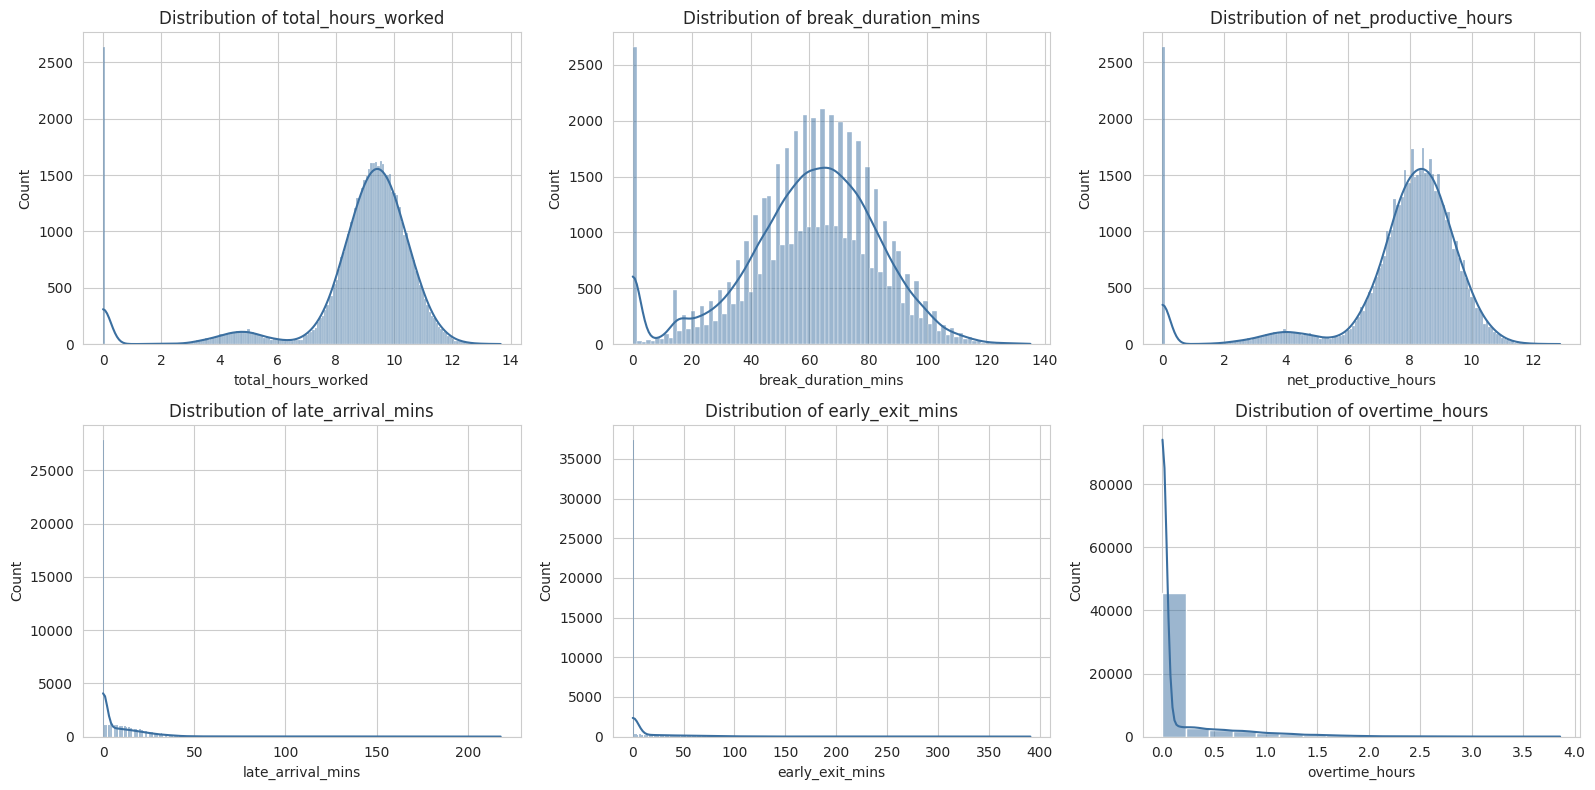

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, numeric_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#3b6fa0")
    ax.set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

### 5.2 Numerical Variable Spread

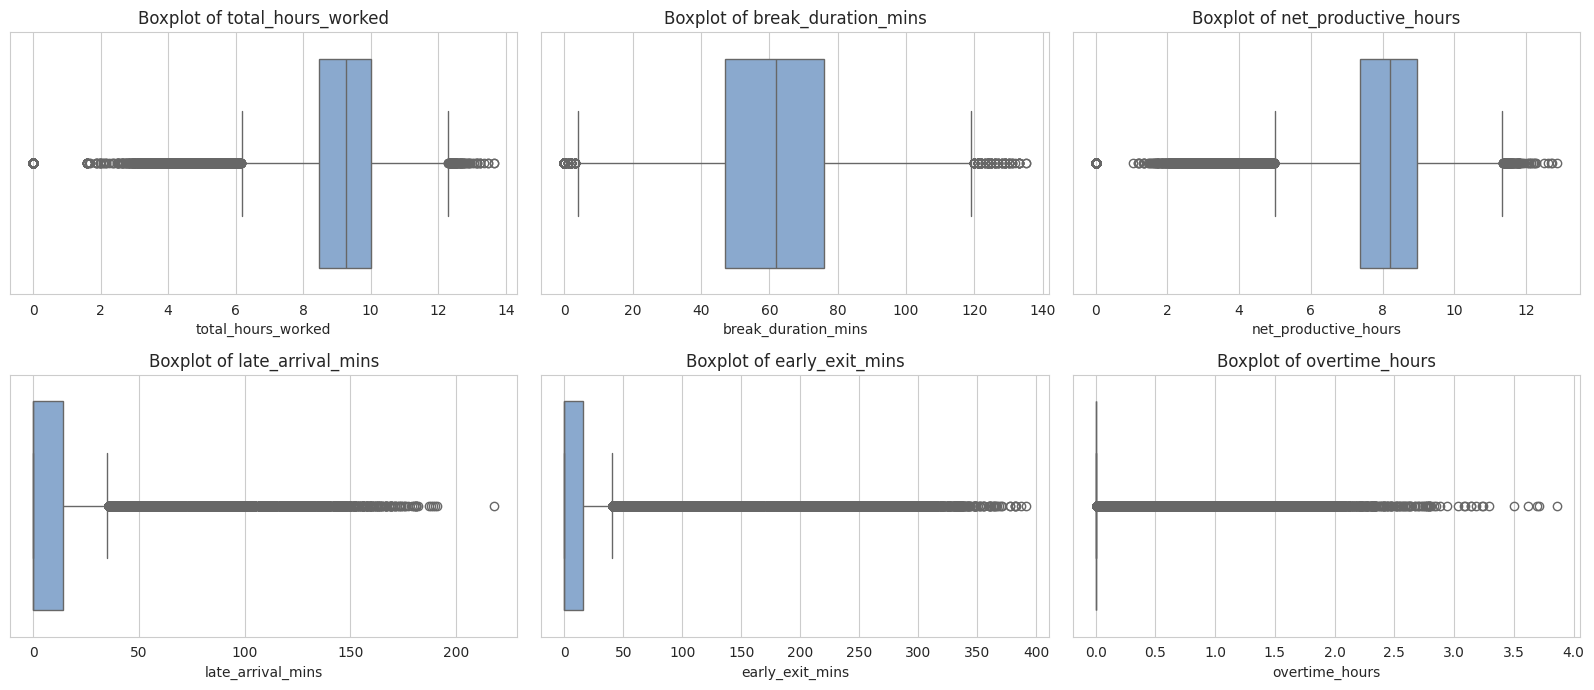

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, c in zip(axes.flat, numeric_cols):
    sns.boxplot(x=df[c], ax=ax, color="#7fa8d9")
    ax.set_title(f"Boxplot of {c}")
plt.tight_layout()
plt.show()

### 5.3 Summary Statistics

In [8]:
summary_stats = df[numeric_cols].agg(["mean", "median", "std",
                                          lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
                                          "skew", "kurt"])
summary_stats.index = ["mean", "median", "std", "mode", "skew", "kurtosis"]
summary_stats

,total_hours_worked,break_duration_mins,net_productive_hours,late_arrival_mins,early_exit_mins,overtime_hours,productivity_ratio
mean,8.724951,59.741955,7.729238,9.858471,20.099198,0.150049,0.883421
median,9.280000,62.000000,8.210000,0.000000,0.000000,0.000000,0.886000
std,2.413434,23.878616,2.223308,19.465159,49.630750,0.367258,0.044010
mode,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.891000
skew,-2.375093,-0.564780,-2.117598,4.199678,3.781683,3.091640,-1.303977
kurtosis,5.810435,0.354510,4.766283,22.954390,16.000083,10.853740,5.673656


### 5.4 Categorical Variable Distribution

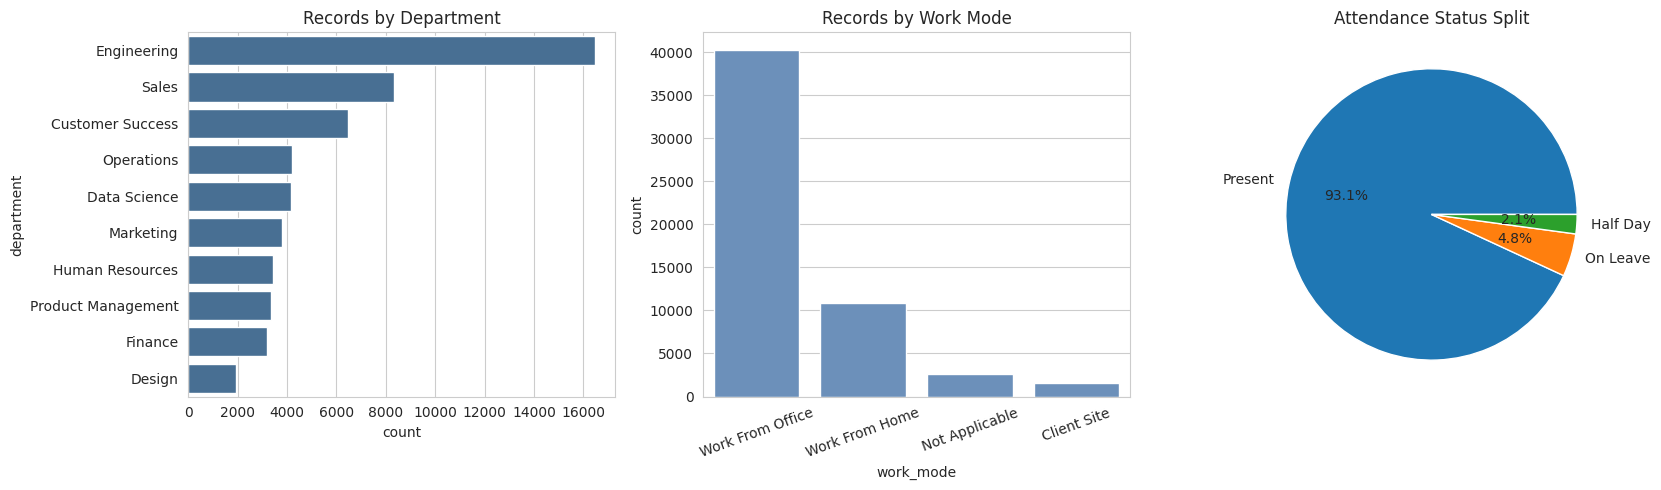

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.countplot(data=df, y="department", order=df["department"].value_counts().index, ax=axes[0], color="#3b6fa0")
axes[0].set_title("Records by Department")

sns.countplot(data=df, x="work_mode", order=df["work_mode"].value_counts().index, ax=axes[1], color="#5f8fc7")
axes[1].set_title("Records by Work Mode"); axes[1].tick_params(axis="x", rotation=20)

df["attendance_status"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[2], ylabel="")
axes[2].set_title("Attendance Status Split")
plt.tight_layout()
plt.show()

## **6. Bivariate Analysis**
Bivariate analysis is used to study the relationship between two variables.

### 6.1 Worked Hours vs Productive Hours

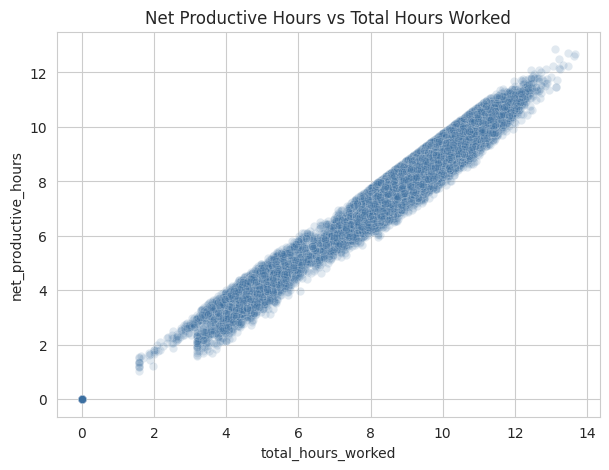

Pearson r = 0.973  (p = 0.00e+00)


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="total_hours_worked", y="net_productive_hours", alpha=0.15, ax=ax, color="#3b6fa0")
ax.set_title("Net Productive Hours vs Total Hours Worked")
plt.show()

worked = df[df["total_hours_worked"] > 0]
pearson_r, pearson_p = stats.pearsonr(worked["total_hours_worked"], worked["net_productive_hours"])
print(f"Pearson r = {pearson_r:.3f}  (p = {pearson_p:.2e})")

### 6.2 Late Arrival Minutes by Department

/tmp/ipykernel_642/95699219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="department", x="late_arrival_mins", ax=ax, palette="Blues")


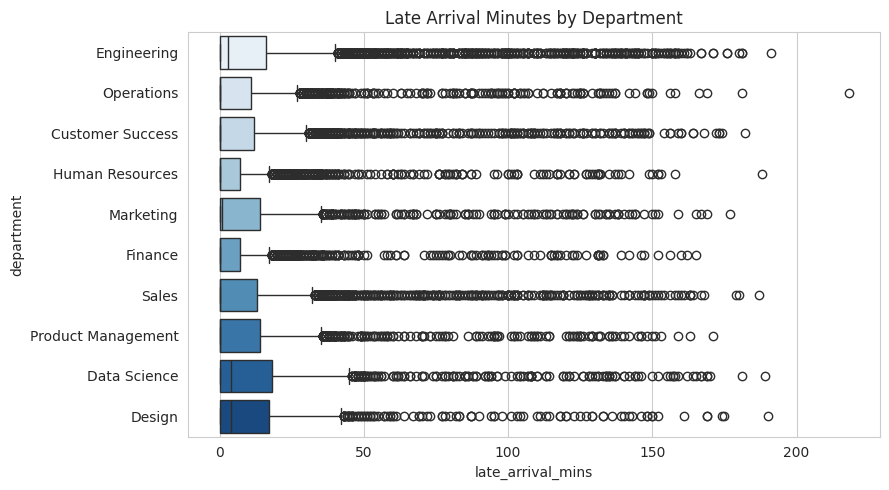

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, y="department", x="late_arrival_mins", ax=ax, palette="Blues")
ax.set_title("Late Arrival Minutes by Department")
plt.tight_layout()
plt.show()

### 6.3 Work Mode Composition by Department

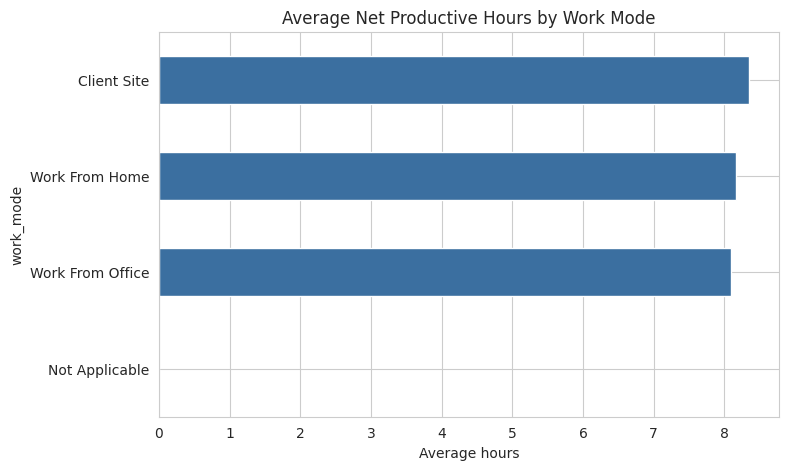

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("work_mode")["net_productive_hours"].mean().sort_values().plot.barh(ax=ax, color="#3b6fa0")
ax.set_title("Average Net Productive Hours by Work Mode")
ax.set_xlabel("Average hours")
plt.show()

### 6.4 Work Mode Composition by Department


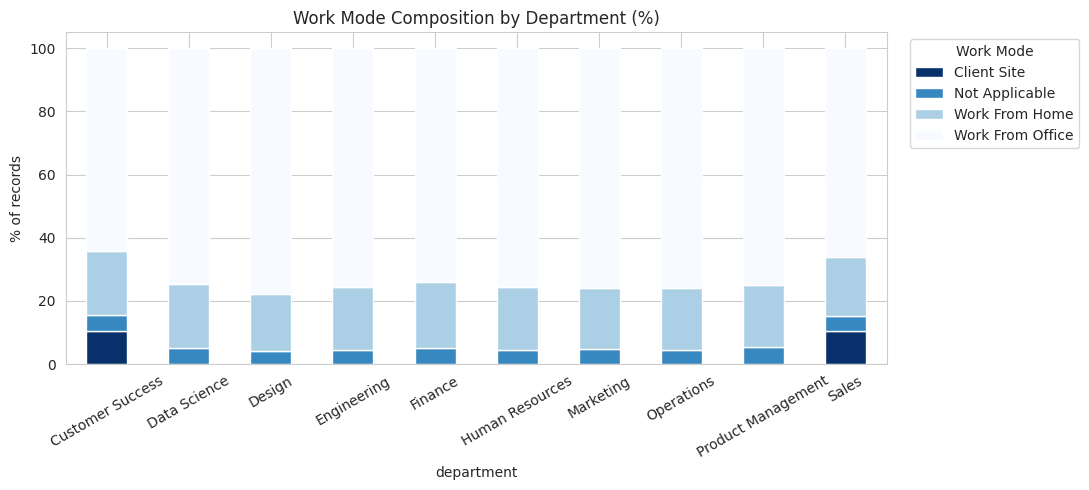

work_mode,Client Site,Not Applicable,Work From Home,Work From Office
department,,,,
Customer Success,10.5,5.0,20.3,64.3
Data Science,0.0,5.2,20.3,74.5
Design,0.0,4.1,18.0,77.9
Engineering,0.0,4.6,19.7,75.7
Finance,0.0,5.0,21.1,73.9
Human Resources,0.0,4.4,20.2,75.5
Marketing,0.0,4.7,19.4,75.9
Operations,0.0,4.6,19.3,76.0
Product Management,0.0,5.3,19.8,74.9


In [13]:
ct = pd.crosstab(df["department"], df["work_mode"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="Blues_r")
plt.title("Work Mode Composition by Department (%)")
plt.ylabel("% of records")
plt.xticks(rotation=30)
plt.legend(title="Work Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
ct.round(1)

## **7. Multivariate Analysis**

Multivariate analysis is used to study patterns and relationships among
multiple variables at the same time.

### 7.1 Pairwise Relationship Analysis

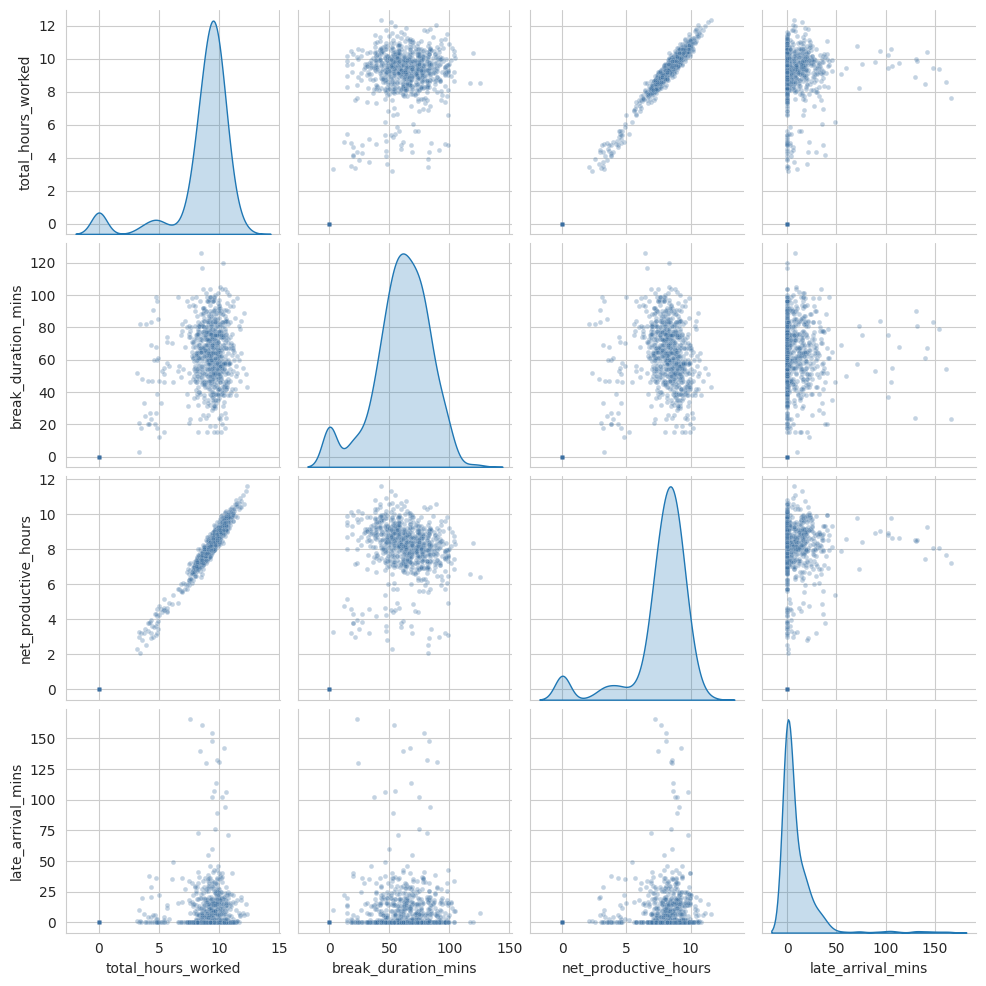

In [14]:
sample_df = df.sample(min(800, len(df)), random_state=42)  # sample for a readable pairplot
sns.pairplot(sample_df[["total_hours_worked", "break_duration_mins", "net_productive_hours",
                         "late_arrival_mins"]].dropna(),
             diag_kind="kde", plot_kws={"alpha": 0.3, "s": 12, "color": "#3b6fa0"})
plt.show()

### 7.2 Correlation Analysis

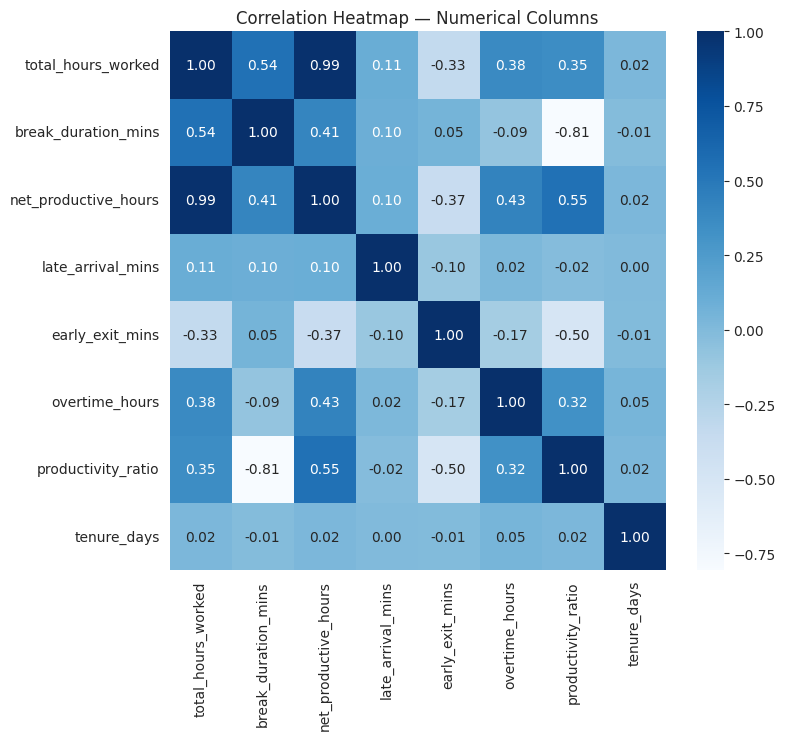

In [15]:
corr = df[numeric_cols + ["tenure_days"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Correlation Heatmap — Numerical Columns")
plt.show()

### 7.3 Late Arrival by Department and Work Mode

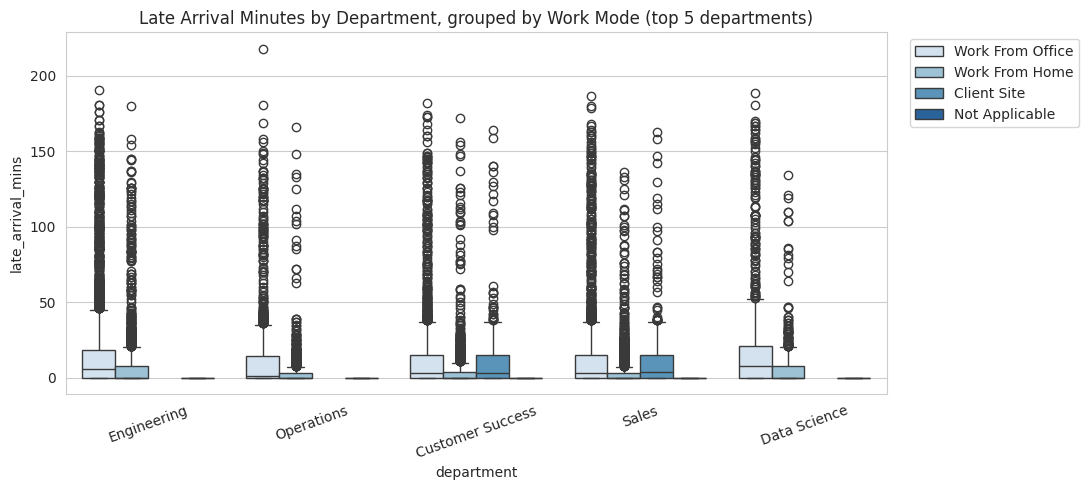

In [16]:
top_depts = df["department"].value_counts().head(5).index
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df[df["department"].isin(top_depts)], x="department", y="late_arrival_mins",
            hue="work_mode", ax=ax, palette="Blues")
ax.set_title("Late Arrival Minutes by Department, grouped by Work Mode (top 5 departments)")
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 7.4 Productive Hours Distribution by Department

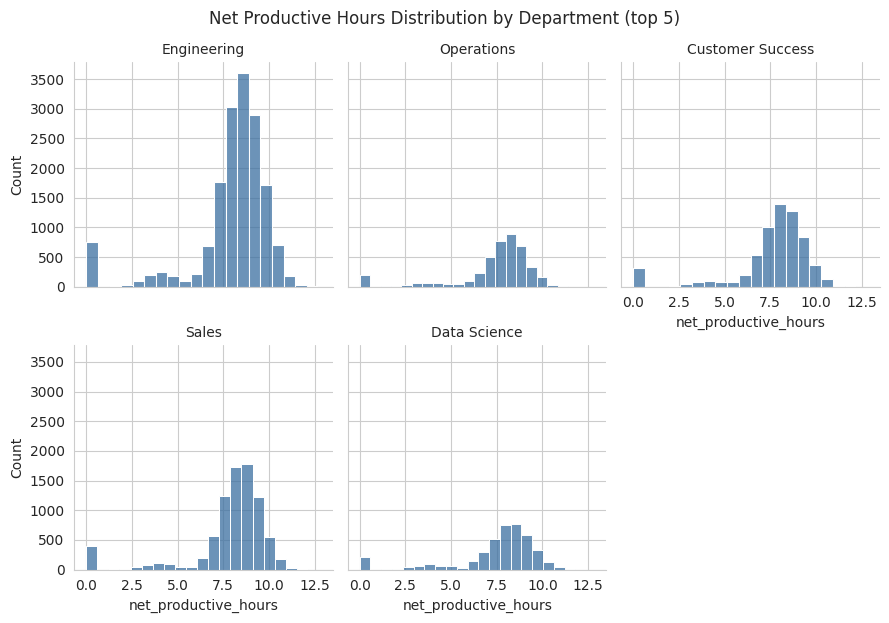

In [17]:
g = sns.FacetGrid(df[df["department"].isin(top_depts)], col="department", col_wrap=3, height=3)
g.map_dataframe(sns.histplot, x="net_productive_hours", color="#3b6fa0", bins=20)
g.set_titles("{col_name}")
g.fig.suptitle("Net Productive Hours Distribution by Department (top 5)", y=1.03)
plt.show()

## **8. Statistical Hypothesis Testing**

Statistical tests are used to check whether the relationships found in the
analysis are statistically significant.


State H₀ (no effect/difference) and H₁ (there is one), then choose the test based on variable types, checking normality (Shapiro-Wilk, on a sample since N is large) and equal variance (Levene's test) first.

### 8.1 Pearson Correlation Test

**Numerical vs Numerical:** Pearson correlation test between `total_hours_worked` and `net_productive_hours`.

*   H₀: There is no linear correlation between hours worked and net productive hours.
*   H₁: There is a linear correlation between hours worked and net productive hours.



In [18]:
worked = df[df["total_hours_worked"] > 0]
r, p = stats.pearsonr(worked["total_hours_worked"], worked["net_productive_hours"])
print(f"Pearson r = {r:.3f}, p-value = {p:.2e}")
print("Reject H0 -> significant correlation" if p < 0.05 else "Fail to reject H0")

Pearson r = 0.973, p-value = 0.00e+00
Reject H0 -> significant correlation


### 8.2 Work Mode and Late Arrival — T-Test

**Numerical vs Categorical (2 groups):** t-test comparing `late_arrival_mins` between Work From Home and Work From Office records.


*   H₀: Mean late-arrival minutes is the same for WFH and WFO.
*   H₁: Mean late-arrival minutes differs between the two groups.



In [19]:
wfh = df.loc[df["work_mode"] == "Work From Home", "late_arrival_mins"].dropna()
wfo = df.loc[df["work_mode"] == "Work From Office", "late_arrival_mins"].dropna()

shapiro_wfh = stats.shapiro(wfh.sample(min(500, len(wfh)), random_state=1))
levene_stat, levene_p = stats.levene(wfh, wfo)
print(f"Shapiro-Wilk (WFH sample) p = {shapiro_wfh.pvalue:.4f}")
print(f"Levene's test p = {levene_p:.4f}")

t_stat, t_p = stats.ttest_ind(wfh, wfo, equal_var=(levene_p > 0.05))
print(f"\nt-statistic = {t_stat:.3f}, p-value = {t_p:.4f}")
print(f"WFH mean late minutes = {wfh.mean():.2f} | WFO mean late minutes = {wfo.mean():.2f}")
print("Reject H0 -> late-arrival minutes differs by work mode" if t_p < 0.05 else "Fail to reject H0")

Shapiro-Wilk (WFH sample) p = 0.0000
Levene's test p = 0.0000

t-statistic = -28.254, p-value = 0.0000
WFH mean late minutes = 6.07 | WFO mean late minutes = 11.50
Reject H0 -> late-arrival minutes differs by work mode


### 8.3 Department and Productive Hours — ANOVA

**Numerical vs Categorical (3+ groups):** one-way ANOVA comparing `net_productive_hours` across department.

*   H₀: Mean net productive hours is the same across all departments.
*   H₁: At least one department has different mean net productive hours.




In [20]:
groups = [g["net_productive_hours"].dropna().values for _, g in df.groupby("department")]
levene_stat, levene_p = stats.levene(*groups)
f_stat, anova_p = stats.f_oneway(*groups)

print(f"Levene's test p = {levene_p:.4f}")
print(f"ANOVA F = {f_stat:.2f}, p-value = {anova_p:.2e}")
print("Reject H0 -> productive hours differ by department" if anova_p < 0.05 else "Fail to reject H0")

df.groupby("department")["net_productive_hours"].mean().round(2).sort_values(ascending=False)

Levene's test p = 0.0000
ANOVA F = 41.46, p-value = 1.35e-74
Reject H0 -> productive hours differ by department


,net_productive_hours
department,
Engineering,7.94
Sales,7.88
Design,7.73
Product Management,7.69
Human Resources,7.63
Marketing,7.62
Customer Success,7.60
Finance,7.50
Data Science,7.49


### 8.4 Department and Work Mode — Chi-Square Test

**Categorical vs Categorical:** Chi-square test of independence between department and work_mode (restricted to working days, since "Not Applicable" work mode is definitionally tied to "On Leave" status).


*   H₀: department and `work_mode` are independent.
*   H₁: department and `work_mode` are associated (remote-work adoption differs by department).



In [21]:
working_days = df[df["attendance_status"] != "On Leave"]
contingency = pd.crosstab(working_days["department"], working_days["work_mode"])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {chi_p:.4f}")
print("Reject H0 -> department and work_mode are associated" if chi_p < 0.05 else "Fail to reject H0")
contingency

Chi-square = 4423.64, dof = 18, p-value = 0.0000
Reject H0 -> department and work_mode are associated


work_mode,Client Site,Work From Home,Work From Office
department,,,
Customer Success,678,1316,4166
Data Science,0,846,3103
Design,0,351,1516
Engineering,0,3240,12455
Finance,0,672,2359
Human Resources,0,694,2599
Marketing,0,734,2873
Operations,0,816,3207
Product Management,0,666,2518


## **9. Dashboard KPI Verification**

### Dashboard Metrics & Business Analysis



*   **Total Employees**

*   **Attendance Rate** (Present +
Half Day ÷ total records)

*   **Leave Rate**
*   **Half Days**
*   **Avg Productivity**

*   **On-Time Arrival Rate** (late_arrival_mins == 0)
*   **Average Productive Hours**

*   **Total Overtime Hours**



In [22]:
kpis = {
    "Total Employees": df["employee_id"].nunique(),
    "Attendance Rate": f'{df["attendance_status"].isin(["Present", "Half Day"]).mean() * 100: .2f}%',
    "Leave Rate": f'{(df["attendance_status"] == "On Leave").mean() * 100: .2f}%',
    "Half Days": (df["attendance_status"] == "Half Day").sum() ,
    "Average Productivity": f'{df["productivity_ratio"].mean() * 100: .2f}%',
    "On-Time Arrival Rate ": f'{(df["late_arrival_mins"] == 0).mean() * 100: .2f}%',
    "Average Productive Hours": f'{df.loc[df["total_hours_worked"] > 0, "net_productive_hours"].mean(): .2f}',
    "Total Overtime Hours": df["overtime_hours"].sum(),
}
kpi_df = pd.DataFrame.from_dict(kpis, orient="index", columns=["value"]).round(2)
kpi_df

,value
Total Employees,980
Attendance Rate,95.24%
Leave Rate,4.76%
Half Days,1186
Average Productivity,88.34%
On-Time Arrival Rate,50.37%
Average Productive Hours,8.12
Total Overtime Hours,8308.79


In [23]:
df.groupby("department")["net_productive_hours"].mean().sort_values(ascending=False).round(2)

,net_productive_hours
department,
Engineering,7.94
Sales,7.88
Design,7.73
Product Management,7.69
Human Resources,7.63
Marketing,7.62
Customer Success,7.60
Finance,7.50
Data Science,7.49


## **10. Dashboard Preparation & Visualisation**

The analysis results were used to design the final three-page Looker Studio
dashboard.



The final Looker Studio dashboard was designed using the cleaned dataset
and the findings from the data analysis.

The dashboard is divided into three pages:
* Page 1. Attendance Overview
* Page 2. Workforce & Work Arrangement
* Page 3. Productivity, Punctuality & Workload


### **Page 1 — Attendance Overview**

This page focuses on overall attendance, leave patterns and weekday attendance behaviour.

**10.1.1 Attendance Status Distribution**

Looker Chart: Donut Chart

In [24]:
attendance_status_summary = (
    df["attendance_status"]
    .value_counts()
    .reset_index()
)

attendance_status_summary.columns = [
    "attendance_status",
    "record_count"
]

attendance_status_summary["percentage"] = (
    attendance_status_summary["record_count"]
    / attendance_status_summary["record_count"].sum()
    * 100
)

display(
    attendance_status_summary.style.format({"percentage": "{:.1f}%"}).hide(
        axis="index"
    )
)

attendance_status,record_count,percentage
Present,51553,93.1%
On Leave,2635,4.8%
Half Day,1186,2.1%


**10.1.2 Monthly Attendance Composition**

Looker Chart: 100% Stacked Column Chart

In [40]:
df["attendance_month_name"] = pd.to_datetime(
    df["attendance_month"], format="%m"
).dt.strftime("%B")

month_order = ["January", "February", "March"]
df["attendance_month_name"] = pd.Categorical(
    df["attendance_month_name"], categories=month_order, ordered=True
)

monthly_attendance = (
    df.groupby(["attendance_month_name", "attendance_status"], observed=False)
    .size()
    .reset_index(name="record_count")
)

monthly_attendance["percentage"] = (
    monthly_attendance.groupby("attendance_month_name", observed=False)["record_count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

monthly_attendance.rename(
    columns={"attendance_month_name": "attendance_month"}, inplace=True
)

display(
    monthly_attendance.style.format({"percentage": "{:.2f}%"}).hide(
        axis="index"
    )
)

attendance_month,attendance_status,record_count,percentage
January,Half Day,365,1.99%
January,On Leave,929,5.07%
January,Present,17040,92.94%
February,Half Day,418,2.26%
February,On Leave,921,4.99%
February,Present,17131,92.75%
March,Half Day,403,2.17%
March,On Leave,785,4.23%
March,Present,17382,93.60%


**10.1.3 Leave Rate by Department**

Looker Chart: Horizontal Bar Chart

In [26]:
leave_rate_department = (
    df.groupby("department")
    .agg(
        total_records=("attendance_status", "count"),
        leave_records=(
            "attendance_status",
            lambda x: (x == "On Leave").sum(),
        ),
    )
    .reset_index()
)

leave_rate_department["leave_rate"] = (
    leave_rate_department["leave_records"]
    / leave_rate_department["total_records"]
) * 100

leave_rate_department = leave_rate_department.sort_values(
    "leave_rate", ascending=False
)

'''
display(
    leave_rate_department[
        ["department", "total_records", "leave_records", "leave_rate"]
    ]
    .style.format({"leave_rate": "{:.2f}%"})
    .hide(axis="index")
)
'''

display(
    leave_rate_department[
        ["department",  "leave_rate"]
    ]
    .style.format({"leave_rate": "{:.2f}%"})
    .hide(axis="index")
)

department,leave_rate
Product Management,5.32%
Data Science,5.16%
Finance,5.04%
Customer Success,4.98%
Sales,4.71%
Marketing,4.70%
Engineering,4.63%
Operations,4.62%
Human Resources,4.36%
Design,4.11%


**10.1.4 On-Time Arrival Rate by Shift Type**

Looker Chart: Horizontal Bar Chart

In [27]:
on_time_arrival_shift = (
    df[df["total_hours_worked"] > 0]
    .groupby("shift_type")
    .agg(
        total_worked_records=("attendance_status", "count"),
        on_time_records=("late_arrival_mins", lambda x: (x == 0).sum()),
    )
    .reset_index()
)

on_time_arrival_shift["on_time_arrival_rate"] = (
    on_time_arrival_shift["on_time_records"]
    / on_time_arrival_shift["total_worked_records"]
) * 100

on_time_arrival_shift = on_time_arrival_shift.sort_values(
    "on_time_arrival_rate", ascending=False
)

'''
display(
    on_time_arrival_shift.style.format({"on_time_arrival_rate": "{:.2f}%"}).hide(
        axis="index"
    )
)
'''

display(
    on_time_arrival_shift[["shift_type", "on_time_arrival_rate"]]
    .style.format({"on_time_arrival_rate": "{:.2f}%"})
    .hide(axis="index")
)

shift_type,on_time_arrival_rate
Early (08:00-17:00),52.89%
Late/US Overlap (14:00-23:00),49.03%
Mid (11:00-20:00),47.98%
General (09:30-18:30),47.87%
Flexible (10:30-19:30),44.94%


**10.1.5 Weekly Attendance Rate Trend**

Looker Chart: Time Series Chart

In [28]:
df["attendance_date"] = pd.to_datetime(df["attendance_date"])

df["week_starting"] = (
    df["attendance_date"]
    - pd.to_timedelta(
        df["attendance_date"].dt.dayofweek,
        unit="D"
    )
)

weekly_attendance = (
    df.groupby("week_starting")
    .agg(
        total_records=("attendance_status", "size"),
        leave_records=(
            "attendance_status",
            lambda x: (x == "On Leave").sum()
        )
    )
    .reset_index()
)

weekly_attendance["attendance_rate"] = (
    1 - (
        weekly_attendance["leave_records"]
        / weekly_attendance["total_records"]
    )
) * 100

weekly_attendance = (
    weekly_attendance[
        ["week_starting", "attendance_rate"]
    ]
    .sort_values("week_starting")
    .round(1)
)

weekly_attendance["week_starting"] = weekly_attendance["week_starting"].dt.strftime('%Y-%m-%d')

display(
    weekly_attendance[["week_starting", "attendance_rate"]]
    .style.format({"attendance_rate": "{:.1f}%"})
    .hide(axis="index")
)

week_starting,attendance_rate
2025-12-29,94.8%
2026-01-05,94.6%
2026-01-12,94.3%
2026-01-19,95.6%
2026-01-26,95.1%
2026-02-02,95.1%
2026-02-09,94.4%
2026-02-16,95.5%
2026-02-23,95.2%
2026-03-02,95.4%


### **Page 2 — Workforce & Work Arrangement**

This page focuses on workforce structure, employment type, work mode,
office location and shift distribution.

**10.2.1 Employment Type Distribution**

Looker Chart: Donut Chart

In [29]:
employment_type_distribution = (
    df.groupby("employment_type")["employee_id"]
    .nunique()
    .reset_index(name="employee_count")
)

employment_type_distribution["percentage"] = (
    employment_type_distribution["employee_count"]
    / df["employee_id"].nunique()
    * 100
)

employment_type_distribution = (
    employment_type_distribution
    .sort_values("employee_count", ascending=False)
    .round(1)
)

display(
    employment_type_distribution.style.format({"percentage": "{:.1f}%"})
    .hide(axis="index")
)

employment_type,employee_count,percentage
Full-Time,809,82.6%
Contract,81,8.3%
Intern,57,5.8%
Part-Time,33,3.4%


**10.2.2 Work Mode Distribution by Department**

Looker Chart: 100% Stacked Vertical Bar Chart

In [30]:
work_mode_department = (
    df[df["work_mode"] != "Not Applicable"]
    .groupby(["department", "work_mode"])
    .size()
    .reset_index(name="records")
)

department_totals = (
    work_mode_department
    .groupby("department")["records"]
    .transform("sum")
)

work_mode_department["percentage"] = (
    work_mode_department["records"]
    / department_totals
    * 100
)

work_mode_department = (
    work_mode_department
    .sort_values(["department", "work_mode"])
    .round(2)
)

work_mode_department.style.hide(axis="index")
display(
    work_mode_department.style.format({"percentage": "{:.2f}%"})
    .hide(axis="index")
)

department,work_mode,records,percentage
Customer Success,Client Site,678,11.01%
Customer Success,Work From Home,1316,21.36%
Customer Success,Work From Office,4166,67.63%
Data Science,Work From Home,846,21.42%
Data Science,Work From Office,3103,78.58%
Design,Work From Home,351,18.80%
Design,Work From Office,1516,81.20%
Engineering,Work From Home,3240,20.64%
Engineering,Work From Office,12455,79.36%
Finance,Work From Home,672,22.17%


**10.2.3 Employees by Office Location**

Looker Chart: Horizontal Bar Chart

In [31]:
employees_by_office = (
    df.groupby("office_location")["employee_id"]
    .nunique()
    .reset_index(name="employee_count")
)

employees_by_office = (
    employees_by_office
    .sort_values("employee_count", ascending=False)
)

employees_by_office.style.hide(axis="index")

office_location,employee_count
Koramangala HQ,317
Whitefield Tech Park,219
HSR Layout Hub,172
Indiranagar Annexe,152
Electronic City Campus,120


**10.2.4 Employees by Shift Type**

Looker Chart: Vertical Bar Chart

In [32]:
employees_by_shift = (
    df.groupby("shift_type")["employee_id"]
    .nunique()
    .reset_index(name="employee_count")
)

employees_by_shift = (
    employees_by_shift
    .sort_values("employee_count", ascending=False)
)

employees_by_shift.style.hide(axis="index")

shift_type,employee_count
General (09:30-18:30),422
Flexible (10:30-19:30),199
Mid (11:00-20:00),142
Late/US Overlap (14:00-23:00),132
Early (08:00-17:00),85


**10.2.5 Employee Headcount by Department**

Looker Chart: Treemap

In [33]:
employee_headcount_department = (
    df.groupby("department")["employee_id"]
    .nunique()
    .reset_index(name="employee_count")
)

employee_headcount_department = (
    employee_headcount_department
    .sort_values("employee_count", ascending=False)
)

employee_headcount_department.style.hide(axis="index")

department,employee_count
Engineering,292
Sales,146
Customer Success,114
Data Science,76
Operations,74
Marketing,67
Human Resources,61
Product Management,59
Finance,56
Design,35


### **Page 3 — Productivity, Punctuality & Workload**

This page focuses on productive hours, working hours, punctuality and overtime.

**10.3.1 Avg Productive Hours by Department**

Looker Chart: Horizontal Bar Chart

In [42]:
avg_productive_hours = (
    df[df["total_hours_worked"] > 0]
    .groupby("department")["net_productive_hours"]
    .mean()
    .reset_index(name="avg_productive_hours")
)

avg_productive_hours = (
    avg_productive_hours
    .sort_values("avg_productive_hours", ascending=False)
)

avg_productive_hours["avg_productive_hours"] = (
    avg_productive_hours["avg_productive_hours"].round(2)
)

display(
    avg_productive_hours.style.format({"avg_productive_hours": "{:.2f} hrs"})
    .hide(axis="index")
)

department,avg_productive_hours
Engineering,8.32 hrs
Sales,8.26 hrs
Product Management,8.12 hrs
Design,8.06 hrs
Customer Success,8.00 hrs
Marketing,8.00 hrs
Human Resources,7.98 hrs
Data Science,7.90 hrs
Finance,7.90 hrs
Operations,7.81 hrs


**10.3.2 Overtime Rate by Department**

Looker Chart: Horizontal Bar Chart

In [35]:
working_df = df[df["total_hours_worked"] > 0].copy()
working_df["has_overtime"] = working_df["overtime_hours"] > 0

overtime_rate_department = (
    working_df.groupby("department")["has_overtime"]
    .mean()
    .mul(100)
    .reset_index(name="overtime_rate")
    .sort_values("overtime_rate", ascending=False)
)

display(
    overtime_rate_department.style.format({"overtime_rate": "{:.1f}%"}).hide(
        axis="index"
    )
)

department,overtime_rate
Engineering,31.7%
Sales,28.3%
Product Management,25.8%
Data Science,23.2%
Customer Success,22.0%
Marketing,19.9%
Design,19.0%
Finance,17.6%
Human Resources,16.9%
Operations,16.6%


**10.3.3 Avg Productive Hours by Work Mode**

Looker Chart: Vertical Bar Chart

In [43]:
avg_productive_hours_work_mode = (
    df[
        (df["work_mode"] != "Not Applicable")
        & (df["total_hours_worked"] > 0)
    ]
    .groupby("work_mode")["net_productive_hours"]
    .mean()
    .reset_index(name="avg_productive_hours")
    .sort_values("avg_productive_hours", ascending=False)
)


display(
    avg_productive_hours_work_mode.style.format({"avg_productive_hours": "{:.2f} hrs"}).hide(
        axis="index"
    )
)

work_mode,avg_productive_hours
Client Site,8.35 hrs
Work From Home,8.16 hrs
Work From Office,8.09 hrs


**10.3.4 Average Late Arrival & Early Exit by Shift**

Looker Chart: Grouped Vertical Bar Chart


In [44]:
shift_summary = (
    df[df["total_hours_worked"] > 0]
    .groupby("shift_type")
    .agg(
        avg_late_arrival_mins=("late_arrival_mins", "mean"),
        avg_early_exit_mins=("early_exit_mins", "mean"),
    )
    .reset_index()
)

shift_summary = shift_summary.sort_values(
    by="avg_late_arrival_mins", ascending=False
)

display(
    shift_summary.style.format(
        {"avg_late_arrival_mins": "{:.2f} mins", "avg_early_exit_mins": "{:.2f} mins"}
    ).hide(axis="index")
)

shift_type,avg_late_arrival_mins,avg_early_exit_mins
Flexible (10:30-19:30),11.23 mins,18.25 mins
Mid (11:00-20:00),10.51 mins,23.32 mins
Late/US Overlap (14:00-23:00),10.20 mins,20.28 mins
General (09:30-18:30),10.13 mins,19.83 mins
Early (08:00-17:00),9.39 mins,31.58 mins


**10.3.5 Productivity Ratio by Department**

Looker Chart: Treemap

In [38]:
dept_productivity = (
    df[df["total_hours_worked"] > 0]
    .groupby("department")["productivity_ratio"]
    .mean()
    .reset_index()
)

dept_productivity = dept_productivity.sort_values(
    by="productivity_ratio", ascending=False
)

dept_productivity["productivity_ratio_pct"] = (
    dept_productivity["productivity_ratio"] * 100
).map("{:.1f}%".format)

display(
    dept_productivity[["department", "productivity_ratio_pct"]].style.hide(
        axis="index"
    )
)

department,productivity_ratio_pct
Sales,88.8%
Customer Success,88.5%
Design,88.5%
Engineering,88.5%
Product Management,88.3%
Human Resources,88.2%
Marketing,88.1%
Finance,87.9%
Operations,87.8%
Data Science,87.7%


## **11. Key Findings**
- The dataset contains attendance records for 980 employees across 10 departments.
- Total hours worked and net productive hours show a very strong positive relationship.
- Late-arrival behaviour differs between Work From Home and Work From Office records.
- Average productive hours are not the same across all departments.
- Work mode usage varies across departments.
- These patterns highlight attendance, punctuality, productivity, and work-mode differences in the workforce.

## **12. Conclusion**

This project provided a structured analysis of employee attendance and productivity
for the Bangalore workforce during Q1 2026.
The analysis combined descriptive
statistics, visual analysis, relationship analysis, and statistical testing to
understand important workforce patterns.
The findings were then used to create
a three-page Looker Studio dashboard with KPIs and interactive visualisations.

Overall, the project converts raw attendance data into clear and useful
information that can support workforce monitoring and better decision-making.
